In [16]:
import pandas as pd
from pycaret.classification import load_model, predict_model
from sklearn.metrics import log_loss, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score


In [7]:
best_model = load_model("../data/06_models/best_model_kedro")

print("Modelo carregado com sucesso!")

Transformation Pipeline and Model Successfully Loaded
Modelo carregado com sucesso!


In [9]:
df_prod = pd.read_parquet("../data/01_raw/dataset_kobe_prod.parquet")

print("Dimensão inicial do df_prod:", df_prod.shape)
df_prod.head(3)

Dimensão inicial do df_prod: (6426, 25)


,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
10,Jump Shot,Jump Shot,309,20000012,33.8063,-94,238,-118.3638,1,3,...,3PT Field Goal,Left Side Center(LC),Above the Break 3,24+ ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,11
17,Jump Shot,Jump Shot,138,20000019,33.8183,-117,226,-118.3868,8,2,...,3PT Field Goal,Left Side Center(LC),Above the Break 3,24+ ft.,1610612747,Los Angeles Lakers,2000-11-01,LAL vs. UTA,UTA,18
27,Jump Shot,Jump Shot,369,20000019,33.8583,-183,186,-118.4528,0,3,...,3PT Field Goal,Left Side Center(LC),Above the Break 3,24+ ft.,1610612747,Los Angeles Lakers,2000-11-01,LAL vs. UTA,UTA,28


In [12]:
relevant_cols = ["lat", "lon", "minutes_remaining", "period", "playoffs", "shot_distance"]

df_prod_filtered = df_prod.dropna(subset=relevant_cols)

# Manter somente as colunas relevantes
df_prod_filtered = df_prod_filtered[relevant_cols + ["shot_made_flag"] 
                                    if "shot_made_flag" in df_prod.columns 
                                    else relevant_cols].dropna()

print("Dimensão do df_prod_filtered:", df_prod_filtered.shape)
df_prod_filtered.head(3)

Dimensão do df_prod_filtered: (5412, 7)


,lat,lon,minutes_remaining,period,playoffs,shot_distance,shot_made_flag
10,33.8063,-118.3638,1,3,0,25,0.0
17,33.8183,-118.3868,8,2,0,25,1.0
27,33.8583,-118.4528,0,3,0,26,0.0


In [13]:
predictions = predict_model(best_model, data=df_prod_filtered)

# ver as colunas e algumas linhas
print("Colunas do DataFrame de predições:", predictions.columns)
predictions.head(3)

Colunas do DataFrame de predições: Index(['lat', 'lon', 'minutes_remaining', 'period', 'playoffs',
       'shot_distance', 'shot_made_flag', 'prediction_label',
       'prediction_score'],
      dtype='object')


,lat,lon,minutes_remaining,period,playoffs,shot_distance,shot_made_flag,prediction_label,prediction_score
10,33.806301,-118.363800,1,3,0,25,0.0,0,0.6629
17,33.818298,-118.386803,8,2,0,25,1.0,0,0.6454
27,33.858299,-118.452797,0,3,0,26,0.0,0,0.6836


In [14]:
if "shot_made_flag" in df_prod_filtered.columns:
    # Descubra se a probabilidade está em "Score" ou "Score_1"
    # Caso você não use raw_score=True, normalmente "Score" é a probabilidade da classe positiva
    y_true = predictions["shot_made_flag"]
    y_pred = predictions["prediction_label"]
    y_proba = predictions["prediction_score"]

    # Calcular métricas
    ll_prod = log_loss(y_true, y_proba)
    f1_prod = f1_score(y_true, y_pred)

    print(f"Log Loss na base de produção: {ll_prod:.4f}")
    print(f"F1 Score na base de produção: {f1_prod:.4f}")
else:
    print("Não há 'shot_made_flag' na base de produção, não é possível calcular métricas supervisionadas.")

Log Loss na base de produção: 0.9081
F1 Score na base de produção: 0.0000


In [ ]:
predictions.to_parquet("../data/07_model_output/scored_prod.parquet", index=False)

print("Predições salvas em: data/07_model_output/scored_prod.parquet")

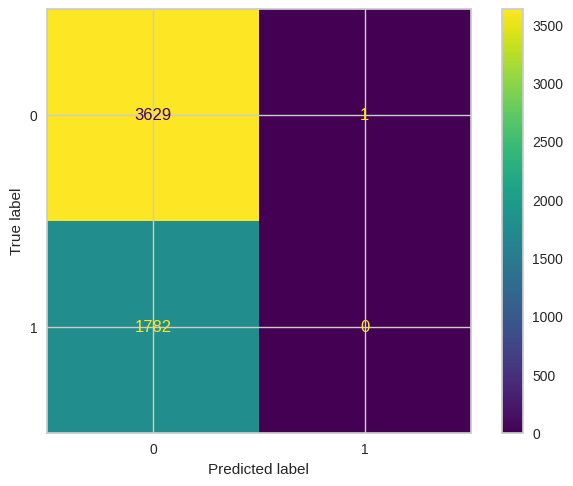

In [18]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot()
plt.show()


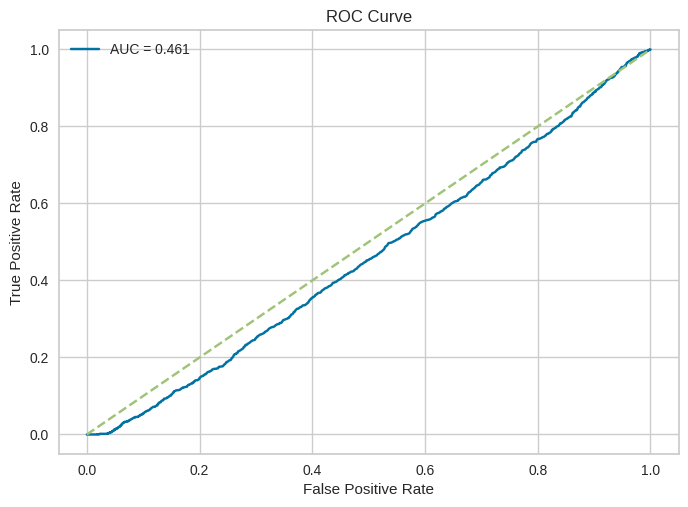

In [19]:
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
auc = roc_auc_score(y_true, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")  # linha diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


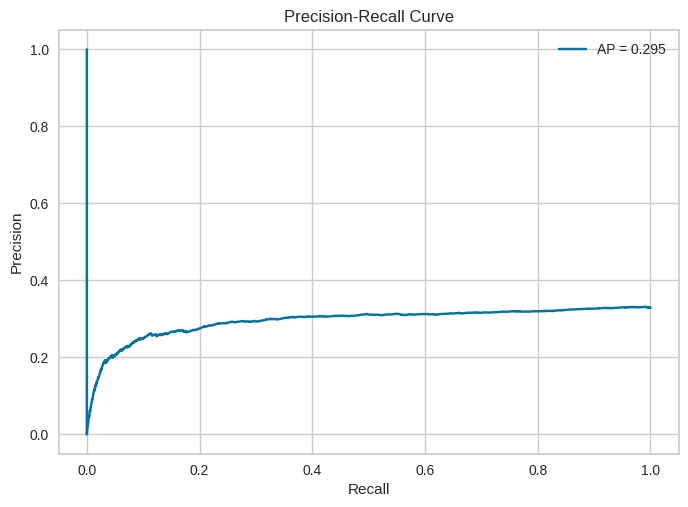

In [20]:

precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)

plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


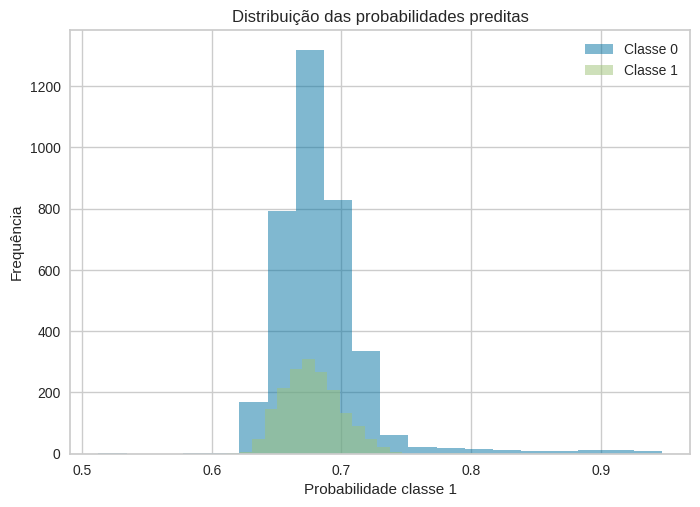

In [21]:
import matplotlib.pyplot as plt

plt.hist(y_proba[y_true==0], bins=20, alpha=0.5, label="Classe 0")
plt.hist(y_proba[y_true==1], bins=20, alpha=0.5, label="Classe 1")
plt.title("Distribuição das probabilidades preditas")
plt.xlabel("Probabilidade classe 1")
plt.ylabel("Frequência")
plt.legend()
plt.show()
